# Variable Star Distance — Progressive Build

A step-by-step distance pipeline for a variable star. The star's type (SX
Phe, RR Lyrae, Cepheid, eclipsing binary, ...) is not assumed up front — the
period–luminosity relation, absolute magnitude, and any type-specific
assumptions get layered in once the type is known or hypothesized.


## The Physics: From Flux to Distance

Every distance measurement here traces back to one relationship: how bright a
star appears depends on how much light it puts out and how far away it is.

**Flux and luminosity.** A star radiates a total luminosity $L$ (energy per
second) equally in all directions. At distance $d$, that light has spread out
over the surface of a sphere of area $4\pi d^2$, so the flux $f$ (energy per
second, per unit area) we receive is:

$$ f = \frac{L}{4\pi d^2} $$

This is the inverse-square law: flux falls off as the square of distance —
double the distance, receive a quarter of the light — regardless of what kind
of star it is.

**From flux to magnitudes.** Astronomical magnitudes are a logarithmic flux
scale (Pogson's law): $m = -2.5\log_{10}(f) + \text{const}$. Compare the
star's actual apparent magnitude $m$ (its flux $f$ at its real distance $d$)
to its absolute magnitude $M$ (the magnitude it *would* have if placed at the
standard reference distance of 10 pc, flux $F_{10}$):

$$ m - M = -2.5\log_{10}\!\left(\frac{f}{F_{10}}\right) $$

Since $f \propto 1/d^2$ (from above) and $F_{10} \propto 1/(10\,\mathrm{pc})^2$,
the luminosity $L$ cancels out of the ratio $f/F_{10}$ entirely, leaving only
distance:

$$ \frac{f}{F_{10}} = \left(\frac{10\,\mathrm{pc}}{d}\right)^{\!2}
   \quad\Longrightarrow\quad m - M = 5\log_{10}(d) - 5 $$

This is the **distance modulus**. Solved for distance (in parsecs):

$$ d = 10^{\,(m - M + 5)/5} $$

$m$ is measurable directly — point a telescope at the star and measure its
flux. $M$ is the problem: it's a property of the star itself, not of us, and
nothing about observing the star's *apparent* brightness tells you how far
away it is without already knowing $M$.


## The Challenge of Measuring Luminosity

You can't point a telescope at a star and read off its luminosity or absolute
magnitude directly — what you measure is flux, and the inverse-square law
above shows flux depends on *both* luminosity and distance at once. A single
flux measurement can't tell you how much of "faint" is "far away" versus "not
very luminous" — to get $M$ you need $d$, but $d$ is exactly what you're
trying to find. That circularity is the deadlock this whole method exists to
break.

**How it was broken: relative, not absolute, brightness.** The breakthrough
came from Henrietta Swan Leavitt at Harvard College Observatory, cataloging
thousands of variable stars in the Small Magellanic Cloud (1908–1912). Every
star in the SMC sits at essentially the same distance from us — the cloud's
own size is negligible next to how far away it is as a whole — so
*differences* in apparent brightness among SMC Cepheids had to be differences
in true luminosity, not distance. Leavitt found that the brighter Cepheids
pulsed more slowly: a clean relationship between period and luminosity,
discovered without ever knowing the actual distance to a single one of them.

That gave the *shape* of the relation (the slope) but not its *zero-point* —
where the line sits in absolute terms — since the SMC's own distance wasn't
yet known. Pinning down the zero-point took decades of further calibration:
statistical parallax, main-sequence fitting in star clusters containing
calibrator variables, and eventually direct geometric parallax from missions
like Hipparcos and Gaia, which measure distance without relying on any
period–luminosity assumption at all. Modern P–L zero-points — including the
SX Phe relation used below — ultimately trace back to Gaia parallaxes of
nearby calibrator stars.

**Why every class of pulsator has its own relation.** A period–luminosity
relation isn't one universal law — it falls out of the physics of *why* a
star pulsates (chiefly the opacity-driven κ-mechanism, sensitive to a star's
mass, radius, temperature, and evolutionary state), so different classes land
on different lines: classical Cepheids (young, massive, Population I), RR
Lyrae (old, lower-mass, Population II — luminosity depends more on
metallicity than period), and SX Phe (evolved low-mass Population II stars
pulsating in a regime that mimics young Cepheids) each have their own slope,
zero-point, and scatter, calibrated independently the same Leavitt-style way.
That's why this notebook keeps its relations in a registry keyed by class
rather than one hardcoded formula — applying the wrong class's relation to a
star gives you a confidently wrong distance, not an approximately right one.


## What This Notebook Needs

Given a calibrated period–luminosity relation to stand in for the $M$ we
can't measure directly, here's how this notebook gets from your observations
to a distance.

**Where the data comes from.** `REPORT_PATH` (in Configuration below) points
at photometry for the target star, from either of two AAVSO sources:

- **A report you generated yourself** — an AAVSO Extended Format file exported
  from VPhot or ASTAP after reducing your own images, transformed or not.
  This is what the notebook has been tested against so far.
- **A download of existing observations from the AAVSO International
  Database** — useful for a star you haven't imaged yourself, or when you
  want a longer public baseline than one of your own sessions provides.

Both are meant to work as a straight drop-in for `REPORT_PATH`; we'll verify
that once we get to Section 3.

**The chain, start to finish.** The only real *input* here is a set of
magnitude-at-time observations, extracted from that report. Everything else
is derived from those observations, or from something derived from them:

1. **Observations** — (time, magnitude) pairs extracted from the report.
2. **$P$** (period) — recovered from the observations via a Lomb–Scargle
   periodogram.
3. **$m$** (apparent magnitude) — also computed from the observations, but
   using $P$: fold them on $P$ and take the intensity mean over one cycle.
4. **$M$** (absolute magnitude) — computed from $P$ via a period–luminosity
   relation, since $M$ itself can't be measured directly (previous section).
5. **$d$** (distance) — computed from $m$ and $M$ via the distance modulus.

| Quantity | Derived from |
|---|---|
| Observations | the AAVSO report |
| $P$ | observations, via Lomb–Scargle |
| $m$ | observations, folded on $P$ (intensity mean) |
| $M$ | $P$, via a period–luminosity relation |
| $d$ | $m$ and $M$, via the distance modulus |

The sections below build each one in turn, in that order: period from
observations, absolute magnitude from period, apparent magnitude from
observations, then distance.


## 1 · Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from astropy.timeseries import LombScargle

print("imports ok")

imports ok


## 2 · Configuration

Everything you'd change for a different report, star, or band lives here —
one place to look before a run, rather than hunting through cells below.


In [2]:
# Example: a full ~4-hour session (218 pts), enough to see several cycles.
# Swap in any AAVSO Extended Format report -- transformed or not, either works.
REPORT_PATH = "/Users/jwatts/Documents/astrophotography/Photometry/AAVSO-Downloads/etaAql.csv"
BAND = "V"
TARGET_NAME = None          # only needed if the report covers more than one star
KNOWN_PERIOD = None         # manual override for the literature period (days) -- Section 3 looks
                            # this up automatically from VSX by star name; set this only if that
                            # lookup is wrong or missing for this star
STAR_LABEL = None           # clean name for plot titles/filenames, and for the VSX (Section 4) /
                            # Gaia (Section 14) lookups -- leave None to use the report's own NAME
                            # field; set only if that field carries free text (dates, spectral
                            # type, ...) rather than a bare star name
P_MIN = None                # explicit manual override for Lomb-Scargle's search window (days) --
P_MAX = None                # leave both None for the normal case. A fixed absolute window doesn't
                            # travel between stars (a window sized for YZ Boo's ~0.10 d period
                            # excludes CY Aqr's ~0.06 d one entirely), so Section 6 instead
                            # auto-narrows around the VSX literature period -- relative to whichever
                            # star is loaded -- using P_SEARCH_HALF_WIDTH_FRAC below, only when the
                            # default window (half the observed baseline) is too short to reach it.
                            # Only set P_MIN/P_MAX here for something the fraction can't express,
                            # e.g. no VSX period found and you want to search a specific range by hand.
P_SEARCH_HALF_WIDTH_FRAC = 0.2   # +/- fraction of the VSX literature period to search when the
                                  # default window can't reach it -- same setting works for any star
                                  # since it's relative to that star's own looked-up period
DUSTMAPS_DATA_DIR = ".dustmaps_data"   # where the local Bayestar19 3D dust map lives (Section
                                       # 11/12) -- relative to this notebook's own directory. Needs
                                       # `pip install dustmaps` and a one-time ~700 MB download
                                       # (run ensure_bayestar_data() once, see Section 11/12); if
                                       # the package or data aren't available, Section 11/12
                                       # proceeds without an extinction correction (A_V=0) instead.

print(f"REPORT_PATH = {REPORT_PATH}")
print(f"BAND = {BAND}, TARGET_NAME = {TARGET_NAME}, KNOWN_PERIOD = {KNOWN_PERIOD}, STAR_LABEL = {STAR_LABEL}")
print(f"P_MIN = {P_MIN}, P_MAX = {P_MAX}, P_SEARCH_HALF_WIDTH_FRAC = {P_SEARCH_HALF_WIDTH_FRAC}")
print(f"DUSTMAPS_DATA_DIR = {DUSTMAPS_DATA_DIR}")


REPORT_PATH = /Users/jwatts/Documents/astrophotography/Photometry/AAVSO-Downloads/etaAql.csv
BAND = V, TARGET_NAME = None, KNOWN_PERIOD = None, STAR_LABEL = None
P_MIN = None, P_MAX = None, P_SEARCH_HALF_WIDTH_FRAC = 0.2
DUSTMAPS_DATA_DIR = .dustmaps_data


In [3]:
# --- period -> absolute magnitude relations ---------------------------------
# Registry of linear P-L relations (M = a + b*log10(P)). Add a new entry here
# to make it selectable via RELATION_NAME below -- see Section 6 for the
# uncertainty model these fields feed into. period_range is the class range
# this relation is actually calibrated over, used for the Error Analysis plot.
PL_RELATIONS = {
    "SXPhe_CohenSarajedini2012": {
        "label": "SX Phe (Cohen & Sarajedini 2012)",
        "a": -1.640, "a_err": 0.110,    # intercept (zero-point)
        "b": -3.389, "b_err": 0.090,    # slope
        "sigma_intrinsic": 0.20,        # star-to-star scatter around the mean line (mag)
        "reference": "Cohen & Sarajedini (2012), M_V = a + b*log10(P_fundamental [days])",
        "period_range": (0.02, 0.20),   # days -- the SX Phe regime this relation covers
    },
    "Cepheid_Benedict2007": {
        "label": "Classical Cepheid, fundamental mode (Benedict et al. 2007)",
        # Benedict et al. (2007, AJ 133, 1810), Table 12, V-band, "B07" column:
        # M_V = -4.05(+/-0.02) - 2.43(+/-0.12)*(logP - 1), from HST FGS trigonometric
        # parallaxes of 10 Galactic Cepheids (including delta Cep itself). Re-centered
        # here on logP=0 (a = a_logP1 - b) to match this registry's M = a + b*log10(P)
        # convention; a_err combines both original terms in quadrature since b's own
        # uncertainty now also affects the logP=0 intercept.
        "a": -1.620, "a_err": 0.123,     # intercept (zero-point), M at P = 1 day
        "b": -2.430, "b_err": 0.120,     # slope
        "sigma_intrinsic": 0.10,         # star-to-star scatter around the mean line (mag)
        "reference": "Benedict et al. (2007), AJ 133, 1810, Table 12 (B07), M_V = a + b*(logP-1) refit to logP=0",
        "period_range": (3.7, 35.6),     # days -- the 10-Cepheid Galactic calibration sample's range
    },
}

RELATION_NAME = "Cepheid_Benedict2007"   # must be a key in PL_RELATIONS above

print(f"RELATION_NAME = {RELATION_NAME} -> {PL_RELATIONS[RELATION_NAME]['label']}")


RELATION_NAME = Cepheid_Benedict2007 -> Classical Cepheid, fundamental mode (Benedict et al. 2007)


## 3 · Load an AAVSO report

Reads photometry from either AAVSO source described above, auto-detected by
format:

- **Extended Format** (VPhot/ASTAP export, transformed or not) — metadata
  lines start with `#`; the column header is itself a `#`-prefixed line. A
  `TransformApplier` report keeps each original untransformed row as a
  commented-out line directly above its `TRANS=YES` replacement, and those,
  along with the TA's own `# Tbv=...` banner lines, are skipped so only the
  live data rows come through.
- **AAVSO International Database (AID) download** — an ordinary CSV with a
  plain header row. Its exact spelling varies between AAVSO's own exports:
  the current one is `#,target,auid,jd,mag,uncertainty,fainterthan,band,...`,
  an older one used `JD,Magnitude,Uncertainty,Band,Star Name`. `AID_COLUMNS`
  maps both onto the same normalized names.

**Detecting which is which.** Extended Format's first line is always a
`#KEY=VALUE` parameter (the spec mandates `#TYPE=EXTENDED` first), so that
shape is what's tested for. Testing for a leading `#` alone is *not* enough:
the current AID export's first column is literally named `#` (it's a row
counter), so its header line starts with `#` too and gets misrouted into the
Extended Format parser, which then fails with "Could not find column header
line".

**Normalizing an AID download.** Beyond column names, two things differ from
an Extended Format export and are reconciled at load time so everything
downstream works the same regardless of source:

- **Band labels.** AID writes full names (`Johnson V`, `Tri-Color Green`);
  Extended Format writes the short `FILT` codes (`V`, `TG`). `AID_BAND_CODES`
  maps them, case-insensitively, so `BAND` in Configuration is the same short
  code either way. An unrecognized band passes through unchanged, so it can
  still be selected by setting `BAND` to its raw label.
- **Non-detections.** AID rows flagged `fainterthan` are upper limits, not
  measurements — averaging them into the intensity mean would bias it faint,
  so they're dropped (and the count reported) rather than silently included.

Either way, the result is normalized onto the same column names (`DATE`,
`MAG`, `MERR`, `FILT`, `NAME`) so everything downstream works the same
regardless of source.

**Resolving the star's identity.** Once loaded, the star's name (`STAR_LABEL`,
or the report's own `NAME` field) is used, in the Run it cell below
(Section 4), to look up a literature period from VizieR's VSX mirror
(`lookup_vsx_period`, the same lookup `vs_catalog.ipynb` uses to build
`vs.json`) — a sanity check on the Lomb–Scargle period recovered in
Section 6. This is best-effort: a name VSX can't resolve just means no
comparison value (`None`), not a hard failure.

Gaia's independent distance is looked up separately, at the very end
(Section 13/14) rather than here — Gaia's TAP service is occasionally slow
or unresponsive, and running it last means a flaky third-party query never
blocks or delays the rest of the pipeline, which doesn't depend on it at
all.


In [4]:
# AAVSO's AID export writes full band names ("Johnson V"); Extended Format
# writes the short FILT codes ("V"). Normalizing here means BAND in
# Configuration stays the same short code regardless of which source is
# loaded. Keys are lowercased for matching, since AID capitalization varies
# ("Tri-Color Green"). Anything not listed passes through unchanged, so an
# unrecognized band can still be selected by setting BAND to its raw label.
# The Johnson/Cousins/Tri-Color/Unfiltered/Visual spellings below are the
# ones real AID exports actually emit; the Sloan entries are inferred from
# the AAVSO filter-code list and haven't been seen in a download here yet.
AID_BAND_CODES = {
    "johnson u": "U", "johnson b": "B", "johnson v": "V",
    "cousins r": "R", "cousins i": "I",
    "sloan u'": "SU", "sloan g'": "SG", "sloan r'": "SR",
    "sloan i'": "SI", "sloan z'": "SZ",
    "tri-color green": "TG", "tri-color blue": "TB", "tri-color red": "TR",
    "unfiltered with v zeropoint": "CV", "unfiltered with r zeropoint": "CR",
    "visual": "VISUAL",
}

# Column spellings seen across AID exports, keyed lowercase. The current
# export's header is "#,target,auid,jd,mag,uncertainty,fainterthan,band,...";
# an older one used "JD,Magnitude,Uncertainty,Band,Star Name". Both map onto
# the same normalized names the Extended Format loader produces.
AID_COLUMNS = {
    "jd": "DATE",
    "mag": "MAG", "magnitude": "MAG",
    "uncertainty": "MERR",
    "band": "FILT",
    "target": "NAME", "star name": "NAME",
}


def load_aavso_report(path):
    """Parse AAVSO photometry from either source format, auto-detected, and
    normalized onto a common set of columns (NAME, DATE, MAG, MERR, FILT).
    """
    path = Path(path)
    first_line = next((l for l in path.read_text().splitlines() if l.strip()), "")
    # Extended Format's first line is a '#KEY=VALUE' parameter (the spec
    # mandates #TYPE=EXTENDED first). An AID CSV can start with '#' too --
    # its row-number column is literally named '#' -- so testing for '#'
    # alone misroutes it here; testing for the '#KEY=' shape doesn't.
    head, sep, _ = first_line.partition("=")
    if sep and head.startswith("#") and head[1:].strip().isalpha():
        return _load_extended_format(path)
    return _load_aid_download(path)


def _load_extended_format(path):
    """AAVSO Extended Format (VPhot/ASTAP export, transformed or not) -- see
    the markdown above for how its '#'-prefixed lines are handled."""
    delim = ","
    header = None
    data_lines = []

    for line in path.read_text().splitlines():
        if not line.strip():
            continue
        if line.startswith("#DELIM="):
            delim = line.split("=", 1)[1].strip()
        elif line.startswith("#NAME" + delim):
            header = line.lstrip("#").split(delim)
        elif line.startswith("#"):
            continue
        else:
            data_lines.append(line.split(delim))

    if header is None:
        raise ValueError(f"Could not find column header line in {path}")

    df = pd.DataFrame(data_lines, columns=header)
    for col in ["DATE", "MAG", "MERR"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def _load_aid_download(path):
    """A CSV downloaded from the AAVSO International Database. Its column
    names and band labels differ from the Extended Format export (and
    between AID exports themselves), so both are normalized here via
    AID_COLUMNS / AID_BAND_CODES -- everything downstream then works the
    same regardless of source."""
    df = pd.read_csv(path, low_memory=False)
    df = df.rename(columns={c: AID_COLUMNS.get(c.strip().lower(), c) for c in df.columns})

    if "FILT" in df.columns:
        df["FILT"] = df["FILT"].map(lambda b: AID_BAND_CODES.get(str(b).strip().lower(), b))

    for col in ["DATE", "MAG", "MERR"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # 'fainterthan' rows are non-detections (upper limits), not measurements --
    # averaging them into the intensity mean would bias it faint.
    if "fainterthan" in df.columns:
        faint = df["fainterthan"].astype(str).str.strip().str.lower() == "true"
        if faint.any():
            print(f"  dropped {int(faint.sum())} 'fainter than' (non-detection) rows")
            df = df.loc[~faint]

    return df


def get_band_series(df, band, target_name=None):
    """Time (JD) and magnitude arrays for one filter, sorted and cleaned,
    ready for period-finding. `target_name` narrows to one star if the report
    covers more than one (rare for a single-target AAVSO submission).
    """
    sel = df["FILT"] == band
    if target_name is not None:
        sel &= df["NAME"] == target_name
    d = df.loc[sel].dropna(subset=["DATE", "MAG"]).sort_values("DATE")
    meta = {
        "target": target_name or (df["NAME"].iloc[0] if len(df) else None),
        "band": band,
        "n_points": len(d),
    }
    return d["DATE"].to_numpy(), d["MAG"].to_numpy(), meta


def plot_raw_data(times, mags, title):
    """Magnitude vs. time for the loaded band -- a first look at the raw
    observations before any period-finding, so gaps, outliers, or trends are
    visible by eye up front."""
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.scatter(times, mags, s=8, alpha=0.5, color="steelblue")
    ax.invert_yaxis()
    ax.set(xlabel="time (JD)", ylabel="magnitude", title=title)
    fig.tight_layout()
    return fig, ax


def lookup_vsx_period(display_name):
    """Look up a star's literature period (days) from VizieR's VSX mirror
    (B/vsx/vsx, hosted by CDS -- not AAVSO, so unaffected by the Cloudflare
    block on www.aavso.org's own VSX API). Adapted from the same lookup
    `vs_catalog.ipynb` uses to build vs.json. Returns a float, or None if the
    name doesn't resolve or VSX has no period on file for it.

    Uses VizieR's `=~` operator (case-insensitive exact match), not `==`
    (case-sensitive exact match) -- confirmed via direct testing that `=~`
    doesn't degrade into a loose/partial match (a prefix like "XX CY" still
    returns nothing). This matters because AID CSV exports write the target
    name in all caps (e.g. "XX CYG"), which doesn't match VSX's own stored
    capitalization ("XX Cyg") under `==` -- silently returning no period
    found. That's not just a missing cross-check: with no literature period,
    Section 6's Lomb-Scargle search window can't auto-narrow and falls back
    to half the observing baseline, which can structurally exclude the true
    period entirely if the baseline is short relative to it (confirmed for
    XX Cyg: true period 0.1349 d, but the 0.161 d baseline capped the
    fallback window at 0.0803 d)."""
    import urllib.request
    import urllib.parse

    params = urllib.parse.urlencode({"-source": "B/vsx/vsx", "-out": "Name,Period"})
    name_param = "Name=~" + urllib.parse.quote(display_name)
    url = f"https://vizier.cds.unistra.fr/viz-bin/asu-tsv?{params}&{name_param}"
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    try:
        with urllib.request.urlopen(req, timeout=20) as resp:
            text = resp.read().decode("utf-8")
    except Exception as e:
        print(f"  VizieR error for {display_name!r}: {e}")
        return None

    lines = [l for l in text.splitlines() if not l.startswith("#")]
    header_idx = next((i for i, l in enumerate(lines) if l.split("\t")[0] == "Name"), None)
    if header_idx is None:
        return None
    data_lines = [l for l in lines[header_idx + 3:] if l.strip()]   # skip header/units/dashes rows
    if not data_lines:
        return None

    period_str = data_lines[0].split("\t")[1].strip()
    try:
        return float(period_str) if period_str else None
    except ValueError:
        return None


def resolve_coords(name):
    """Look up an object's ICRS coordinates by name via SIMBAD."""
    from astroquery.simbad import Simbad
    from astropy.coordinates import SkyCoord
    import astropy.units as u

    res = Simbad.query_object(name)
    if res is None or len(res) == 0:
        raise RuntimeError(f"SIMBAD could not resolve '{name}'")
    # SIMBAD returns RA/Dec; column names vary by astroquery version
    ra_col = "ra" if "ra" in res.colnames else "RA"
    dec_col = "dec" if "dec" in res.colnames else "DEC"
    val_ra, val_dec = res[ra_col][0], res[dec_col][0]
    try:
        c = SkyCoord(float(val_ra) * u.deg, float(val_dec) * u.deg, frame="icrs")
    except (ValueError, TypeError):
        c = SkyCoord(str(val_ra), str(val_dec), unit=(u.hourangle, u.deg), frame="icrs")
    return c.ra.deg, c.dec.deg


print("load_aavso_report + get_band_series + plot_raw_data + lookup_vsx_period + resolve_coords defined")


load_aavso_report + get_band_series + plot_raw_data + lookup_vsx_period + resolve_coords defined


## 4 · Run it

Loads the report, resolves the star's literature period (VSX), plots the
raw observations, and prints a short summary of what we're working with
before Stage 1 begins.

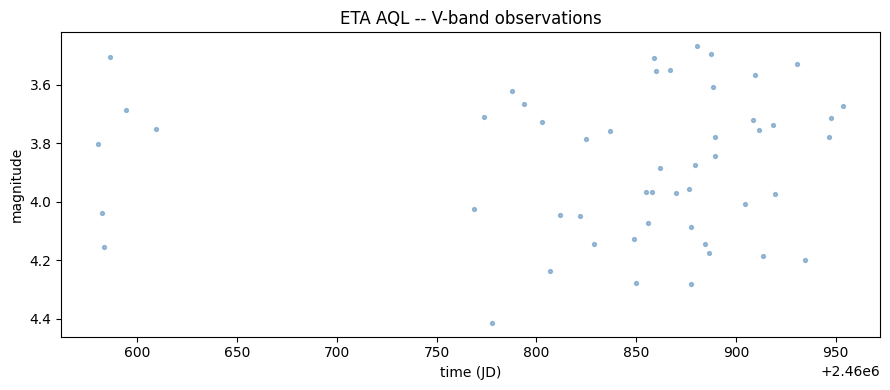


star          : ETA AQL
band          : V
observations  : 51 points, spanning 372.993 d
VSX period    : 7.176790 d  (10334.578 min)


In [5]:
df = load_aavso_report(REPORT_PATH)
times, mags, meta = get_band_series(df, BAND, target_name=TARGET_NAME)
label = STAR_LABEL or meta["target"]

vsx_period = lookup_vsx_period(label) if label else None
literature_period = KNOWN_PERIOD if KNOWN_PERIOD else vsx_period

if meta["n_points"] == 0:
    print(f"No {BAND}-band points in this report to plot.")
else:
    fig, ax = plot_raw_data(times, mags, title=f"{label} -- {BAND}-band observations")
    plt.show()

period_str = f"{vsx_period:.6f} d  ({vsx_period*1440:.3f} min)" if vsx_period else "not found"

print()
print(f"star          : {label}")
print(f"band          : {BAND}")
print(f"observations  : {meta['n_points']} points"
     + (f", spanning {times.max()-times.min():.3f} d" if meta["n_points"] else ""))
print(f"VSX period    : {period_str}")

## 5 · Step 1 — Period from observations (Lomb–Scargle)

AAVSO data isn't evenly sampled — clouds, meridian flips, one visit a night —
so a plain Fourier transform doesn't apply cleanly. **Lomb–Scargle** is built
for exactly that case: it tests a dense grid of candidate frequencies
(equivalently, candidate periods) and scores each one by how well a sinusoid
at that frequency fits the scattered data. That score is called *power* — high
power means the data fold into a strong, coherent repeating pattern at that
period; low power means they don't.

**What the function returns.** `LombScargle(times, mags).autopower(...)`
returns two equal-length arrays: `freq` (the frequency grid it tested, in
cycles/day) and `power` (the fit quality at each frequency). That pair *is*
the periodogram — there's no single "period" value in the return, just power
as a function of frequency.

**How to get the period from it.** Find the index of the highest power
(`argmax(power)`), then invert that frequency: `period = 1 / freq[argmax(power)]`.
Inverting the whole `freq` array the same way (`1 / freq`) gives a period axis
for plotting the periodogram directly, which is what the cell below does.

Because the star's type isn't assumed, the search window (`p_min`/`p_max`)
defaults from the data itself rather than a class-specific pulsation range:
`p_max` defaults to half the observed time baseline (Lomb–Scargle can't
meaningfully constrain a period longer than that), and `p_min` defaults to
0.01 d (~14 min). If the report's time baseline is too short to even reach
`p_min` (e.g. a short test/calibration upload rather than a full session),
the function raises a clear error instead of silently returning a
meaningless result.

**When the default window isn't right for a star.** A baseline of only ~1
cycle or less is the case this can't catch on its own: `p_max` (half the
baseline) then ends up *shorter than the true period*, so the search window
silently excludes it rather than erroring — Lomb–Scargle just returns the
best fit it can find within too-small a window, with no warning. The Run it
cell below catches this itself, using the VSX literature period already
looked up in Section 4: when the default `p_max` would exclude it, the
search window auto-narrows to `P_SEARCH_HALF_WIDTH_FRAC` (Configuration, a
*fraction* of the literature period — e.g. ±20%) around that period instead.
Being relative rather than an absolute day range, the same setting works for
any star switched into `REPORT_PATH` without touching it — unlike setting
`P_MIN`/`P_MAX` directly, which are sized to one specific star's period and
silently break a different star (a window sized for YZ Boo's ~0.10 d period
excludes CY Aqr's ~0.06 d one entirely). `P_MIN`/`P_MAX` still exist for the
rare case the fraction can't express, e.g. no VSX period found at all.


In [6]:
def find_period(times, mags, p_min=None, p_max=None, samples_per_peak=10):
    """Recover the dominant period via Lomb-Scargle. Returns (best_period,
    diagnostics) -- see the markdown above for what's in the periodogram and
    how best_period is derived from it."""
    times = np.asarray(times, float)
    mags = np.asarray(mags, float)

    baseline = times.max() - times.min()
    if p_max is None:
        p_max = baseline / 2
    if p_min is None:
        p_min = 0.01

    if p_max <= p_min:
        raise ValueError(
            f"time baseline ({baseline*1440:.1f} min) is too short to search "
            f"periods as long as p_min ({p_min*1440:.1f} min) -- need more data, "
            f"or pass an explicit shorter p_min"
        )

    f_min, f_max = 1.0 / p_max, 1.0 / p_min

    ls = LombScargle(times, mags)
    freq, power = ls.autopower(minimum_frequency=f_min, maximum_frequency=f_max,
                               samples_per_peak=samples_per_peak)

    best_idx = int(np.argmax(power))
    best_period = 1.0 / freq[best_idx]

    diag = {
        "freq": freq,
        "power": power,
        "period_grid": 1.0 / freq,
        "best_period": best_period,
        "best_power": power[best_idx],
        "false_alarm_probability": ls.false_alarm_probability(power[best_idx]),
        "p_min": p_min,
        "p_max": p_max,
    }
    return best_period, diag


def plot_periodogram(diag, title, known_period=None):
    """Power vs. period, marking the recovered peak and an optional literature
    reference period."""
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(diag["period_grid"], diag["power"], lw=0.8, color="steelblue")
    ax.axvline(diag["best_period"], color="crimson", lw=1.5,
               label=f"recovered = {diag['best_period']:.6f} d")
    if known_period:
        ax.axvline(known_period, color="green", ls="--", lw=1.5,
                   label=f"literature = {known_period:.6f} d")
    ax.set(xlabel="Period (days)", ylabel="Lomb-Scargle power", title=title)
    ax.legend()
    fig.tight_layout()
    return fig, ax


print("find_period + plot_periodogram defined")


find_period + plot_periodogram defined


## 6 · Run it

Runs the Lomb–Scargle period search on the observations loaded and
summarized in Section 4 above.

recovered period : 7.186761 d  (10348.936 min)
best-peak power  : 0.7960
false-alarm prob : 3.20e-14
search window    : 0.0100-186.4964 d
literature period: 7.176790 d  (10334.578 min)
delta (rec-lit)  : +0.009971 d  (+14.358 min)


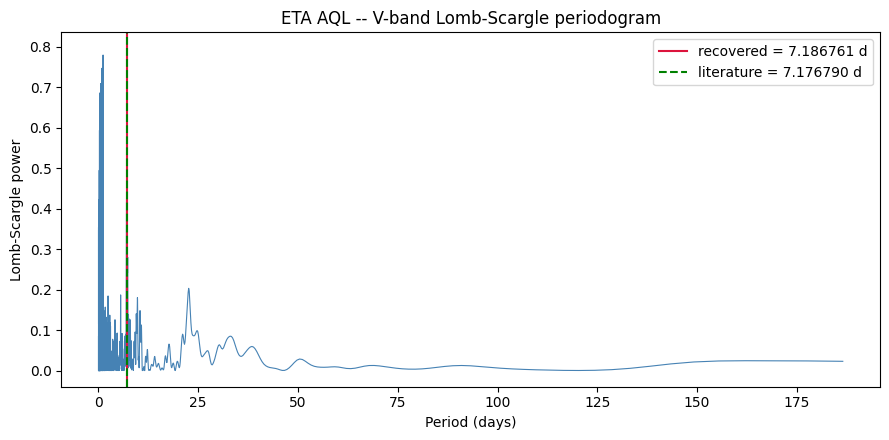

In [7]:
if meta["n_points"] < 2:
    print(f"Not enough {BAND}-band points in this report to run Lomb-Scargle.")
else:
    p_min, p_max = P_MIN, P_MAX
    if literature_period and p_min is None and p_max is None:
        default_p_max = (times.max() - times.min()) / 2
        if default_p_max < literature_period:
            p_min = literature_period * (1 - P_SEARCH_HALF_WIDTH_FRAC)
            p_max = literature_period * (1 + P_SEARCH_HALF_WIDTH_FRAC)
            print(f"note: default p_max ({default_p_max:.4f} d) is shorter than the VSX literature "
                 f"period ({literature_period:.6f} d) -- auto-narrowing the search window to "
                 f"{p_min:.4f}-{p_max:.4f} d around it (+/-{P_SEARCH_HALF_WIDTH_FRAC*100:.0f}%). Set "
                 f"P_MIN/P_MAX explicitly in Configuration to override this.")

    try:
        period, diag = find_period(times, mags, p_min=p_min, p_max=p_max)
    except ValueError as exc:
        period, diag = None, None
        print(f"Could not determine a period: {exc}")

    if diag is not None:
        print(f"recovered period : {period:.6f} d  ({period*1440:.3f} min)")
        print(f"best-peak power  : {diag['best_power']:.4f}")
        print(f"false-alarm prob : {diag['false_alarm_probability']:.2e}")
        print(f"search window    : {diag['p_min']:.4f}-{diag['p_max']:.4f} d")
        if literature_period:
            delta = period - literature_period
            print(f"literature period: {literature_period:.6f} d  ({literature_period*1440:.3f} min)")
            print(f"delta (rec-lit)  : {delta:+.6f} d  ({delta*1440:+.3f} min)")

        fig, ax = plot_periodogram(
            diag, title=f"{label} -- {BAND}-band Lomb-Scargle periodogram",
            known_period=literature_period,
        )
        plt.show()

## 7 · Step 2 — Absolute magnitude from period (P–L relation)

A period–luminosity (P–L) relation says how bright a star truly is (its
absolute magnitude) as a function of its pulsation period. Different classes
of pulsating variable — SX Phe, classical Cepheids, RR Lyrae, ... — each have
their own relation, but many are well approximated by a straight line in
log-period space:

    M = a + b · log10(P)

where `a` is the intercept (zero-point) and `b` is the slope, both empirically
calibrated against stars with independently known distances (e.g. via Gaia
parallax).

**Selecting a relation.** `PL_RELATIONS`, defined in the Configuration section
above, is a registry of these linear relations by name. Right now it holds
only the SX Phe relation from Cohen & Sarajedini (2012) — the one already used
elsewhere in this project for CY Aqr — deliberately: coefficients for other
classes aren't verified anywhere in this repo yet, and a presentation isn't
the place to guess at them. `RELATION_NAME` picks which entry to apply. To add
another class's relation once you have a sourced value for it, add an entry to
`PL_RELATIONS` with its own `a`/`a_err`/`b`/`b_err`/`sigma_intrinsic`, then
point `RELATION_NAME` at it — no other code changes needed.

**What `period_to_absmag` returns.** A tuple `(M, M_err)` — the absolute
magnitude and its 1-sigma uncertainty. The uncertainty combines two things
that answer different questions: how well the *mean* relation itself is known
(from `a_err`/`b_err`, plus your period's own uncertainty if you supply one),
and — when `include_intrinsic=True` (the default) — the relation's intrinsic
scatter (`sigma_intrinsic`), which is how much one real star typically
deviates from the mean line even with the mean line known perfectly. For
predicting a single star's own distance, the intrinsic-scatter version is the
honest number: it dominates, and represents the astrophysical floor of this
whole exercise, not just calibration error.


In [8]:
def period_to_absmag(period, relation_name, period_err=0.0, include_intrinsic=True):
    """Absolute magnitude from a period via the linear P-L relation named
    `relation_name` in PL_RELATIONS. Returns (M, M_err) -- see the markdown
    above for what the two uncertainty components mean."""
    rel = PL_RELATIONS[relation_name]
    a, a_err = rel["a"], rel["a_err"]
    b, b_err = rel["b"], rel["b_err"]
    sigma_intrinsic = rel["sigma_intrinsic"]

    logP = np.log10(period)
    M = a + b * logP

    sig_logP = period_err / (period * np.log(10))
    var_cal = a_err**2 + (logP * b_err)**2 + (b * sig_logP)**2
    var_M = var_cal + (sigma_intrinsic**2 if include_intrinsic else 0.0)
    return M, np.sqrt(var_M)


print("period_to_absmag defined")


period_to_absmag defined


## 8 · Run it

In [9]:
if period is None:
    print("No period available from Stage 1 -- run that cell successfully first.")
else:
    rel = PL_RELATIONS[RELATION_NAME]
    M_V, M_err = period_to_absmag(period, RELATION_NAME)
    M_V_cal, M_err_cal = period_to_absmag(period, RELATION_NAME, include_intrinsic=False)

    print(f"relation          : {rel['label']}")
    print(f"reference         : {rel['reference']}")
    print(f"period used       : {period:.6f} d")
    print(f"M_V (+ intrinsic) : {M_V:.3f} +/- {M_err:.3f}")
    print(f"M_V (calibration) : {M_V_cal:.3f} +/- {M_err_cal:.3f}")


relation          : Classical Cepheid, fundamental mode (Benedict et al. 2007)
reference         : Benedict et al. (2007), AJ 133, 1810, Table 12 (B07), M_V = a + b*(logP-1) refit to logP=0
period used       : 7.186761 d
M_V (+ intrinsic) : -3.701 +/- 0.189
M_V (calibration) : -3.701 +/- 0.160


## 9 · Step 3 — Apparent magnitude from observations (fold and mean)

The naive approach — just average every magnitude reading — is biased two
ways, and folding on the period fixes both.

**Bias 1: averaging happens in the wrong space.** Magnitudes are a
logarithmic scale; flux (brightness) is linear. The average of a set of
magnitudes is *not* the magnitude of the average flux — converting to flux,
averaging, then converting back gives a different (and correct) answer. This
is the same "intensity mean" idea used throughout this project: what you want
is the mean brightness the star actually emitted, not the mean of a nonlinear
transform of it.

**Bias 2: raw samples aren't spread evenly across the cycle.** A pulsating
star spends more real time near some phases of its cycle than others (e.g.
lingering longer near minimum), and your own observing cadence adds further
unevenness on top of that. A plain average silently over-weights whichever
phase happens to have more data points — by luck of scheduling, not by
anything physical.

**How folding fixes both.** `fold_and_mean` uses `period` to map every
observation's timestamp onto a phase from 0 to 1 (`((t - t0) / period) % 1`),
bins the phases uniformly, flux-averages *within* each bin, and only then
averages the bins together — so every part of the cycle counts once,
regardless of how many raw points happened to land there. Empty bins (phases
with no coverage at all) are skipped rather than invented, and reported as a
coverage fraction so any gap stays visible rather than silently smoothed over.

**What it returns.** A tuple `(V_mean, diag)`: `V_mean` is the intensity-mean
apparent magnitude — the answer to use as $m$. `diag` carries everything used
to compute it, including `V_naive` (the plain mean, for comparison) and
`coverage`/`n_empty` (how much of the phase cycle was actually observed).

**A rough cross-check, later.** Gaia's own mean apparent magnitude (`G_mag`)
is a plausible reference point for `V_mean` — but it's not apples-to-apples
(Gaia's G band isn't Johnson V, and `G_mag` is a mean over Gaia's own
unfolded epochs, not a phase-folded intensity mean), and it isn't worth
blocking this step to fetch. It's shown as a labeled reference in the final
summary table (Section 13/14) instead, alongside the other Gaia comparisons.


In [10]:
def fold_and_mean(times, mags, period, t0=None, n_bins=20):
    """Intensity-mean apparent magnitude over one folded pulsation cycle.
    Returns (V_mean, diag) -- see the markdown above for what's in diag and
    why V_mean isn't just mags.mean()."""
    times = np.asarray(times, float)
    mags = np.asarray(mags, float)

    if t0 is None:
        t0 = times.min()

    phase = ((times - t0) / period) % 1.0
    flux = 10**(-0.4 * mags)

    edges = np.linspace(0.0, 1.0, n_bins + 1)
    idx = np.clip(np.digitize(phase, edges) - 1, 0, n_bins - 1)

    bin_flux = np.full(n_bins, np.nan)
    bin_n = np.zeros(n_bins, int)
    for b in range(n_bins):
        sel = idx == b
        bin_n[b] = sel.sum()
        if bin_n[b] > 0:
            bin_flux[b] = flux[sel].mean()

    occupied = bin_n > 0
    mean_flux = np.nanmean(bin_flux[occupied])
    V_mean = -2.5 * np.log10(mean_flux)

    diag = {
        "phase": phase, "mags": mags,
        "bin_centers": 0.5 * (edges[:-1] + edges[1:]),
        "bin_mag": -2.5 * np.log10(bin_flux),
        "bin_n": bin_n, "occupied": occupied,
        "n_empty": int((~occupied).sum()), "coverage": occupied.mean(),
        "V_mean": V_mean, "V_naive": mags.mean(), "period": period,
    }
    return V_mean, diag


def plot_folded(diag, title):
    """Folded light curve with binned means; empty (gap) bins highlighted."""
    bc, bm = diag["bin_centers"], diag["bin_mag"]
    fig, ax = plt.subplots(figsize=(9, 5))
    for shift in (0, 1):
        ax.scatter(diag["phase"] + shift, diag["mags"], s=8, alpha=0.4,
                   color="gray", label="data" if shift == 0 else None)
        ax.plot(bc + shift, bm, "o-", color="crimson",
                label="phase-binned mean" if shift == 0 else None)
    ax.axhline(diag["V_mean"], ls="--", color="navy",
               label=f"intensity mean = {diag['V_mean']:.3f}")
    w = 1.0 / len(bc)
    for c, occ in zip(bc, diag["occupied"]):
        if not occ:
            for shift in (0, 1):
                ax.axvspan(c + shift - w/2, c + shift + w/2, color="orange", alpha=0.2)
    ax.invert_yaxis()
    ax.set(xlabel="phase", ylabel="magnitude", title=title)
    ax.legend(loc="best")
    fig.tight_layout()
    return fig, ax


print("fold_and_mean + plot_folded defined")


fold_and_mean + plot_folded defined


## 10 · Run it

intensity mean m : 3.855 V
naive mean m     : 3.873 V  (bias = +0.018)
phase coverage   : 95%  (1 empty bins of 20)


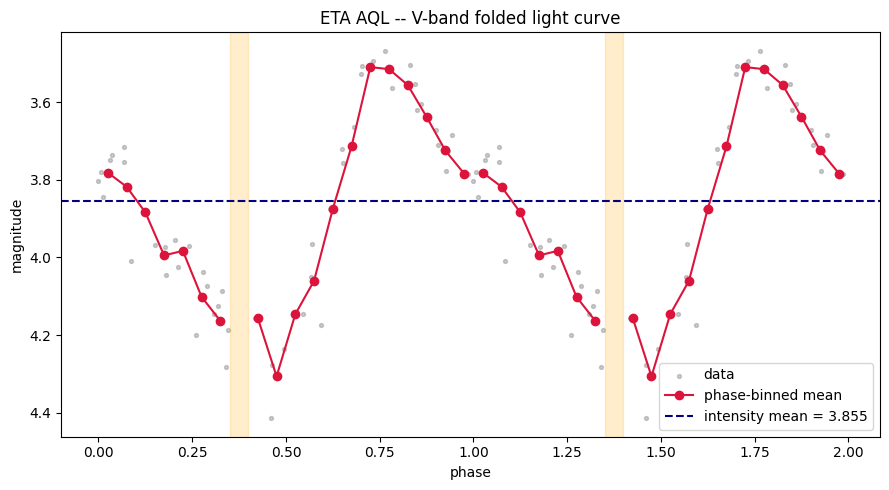

In [11]:
if period is None:
    print("No period available from Stage 1 -- run that cell successfully first.")
else:
    m, fold_diag = fold_and_mean(times, mags, period)

    print(f"intensity mean m : {m:.3f} {BAND}")
    print(f"naive mean m     : {fold_diag['V_naive']:.3f} {BAND}  (bias = {fold_diag['V_naive'] - m:+.3f})")
    print(f"phase coverage   : {100*fold_diag['coverage']:.0f}%  "
         f"({fold_diag['n_empty']} empty bins of {len(fold_diag['bin_centers'])})")

    fig, ax = plot_folded(fold_diag, title=f"{label} -- {BAND}-band folded light curve")
    plt.show()

## 11 · Step 4 — Extinction along this sightline

Dust between us and this star dims and reddens its light — interstellar
extinction, $A_V$ (magnitudes) — and it's been sitting in this notebook's
own distance-modulus formula the whole time, unused:

$$ d = 10^{\,(m - M - A_V + 5)/5} $$

Ignoring it (`A_V = 0`, this notebook's assumption originally) makes the
computed distance too *large*: with $A_V$ left out, some of the star's real
faintness — caused by dust, not distance — gets misattributed to being
farther away.

**Bayestar19 (3D).** Green et al. (2019) built a dust map that resolves
reddening *by distance* along the line of sight, not just by sky position —
a genuine point estimate at this star's own actual distance, with real
uncertainty from the map's own posterior. Needs `pip install dustmaps` and a
one-time ~700 MB local download (`ensure_bayestar_data()`, defined below —
run it once, deliberately, it's a real download). If it isn't available, or
the star falls outside the map's footprint (declination > $-30°$ only), this
section proceeds without an extinction correction ($A_V=0$) rather than
falling back to a coarser map — an earlier version of this notebook fell
back to NASA/IPAC's 2D `IrsaDust` map (integrated to infinity along the
sightline, not resolved by distance) whenever the 3D lookup failed, but that
was masking what was actually a one-time package/VPN setup issue rather than
a real, recurring gap in Bayestar19's coverage. Worth reintroducing a 2D (or
other) fallback if Bayestar19 turns out to fail for reasons other than setup.

**A wrinkle: querying "distance-resolved" extinction needs a distance.**
Before this section runs, all we have is the *un*corrected distance
(assuming $A_V=0$) from Section 8's $M_V$ and this star's own $m$ — computed
inline below as a preliminary estimate, purely to know where along the
sightline to query. Real dust corrections are usually a small fraction of
the total distance, so this converges well enough in a single pass; Step 5
below computes the actual, final distance properly, using the extinction
value this section finds.

**Where Bayestar19's coefficient comes from.** The map's own published
table (Green et al. 2019, Table 1) only gives conversion coefficients for
Pan-STARRS 1 and 2MASS bands, not Johnson V — but it's built from "the
$R_V=3.3$ empirical reddening vector from Schlafly et al.," the same
reddening law behind the Schlafly & Finkbeiner (2011) recalibration.
Bridging through 2MASS $K_s$ gives an exact (not approximated by a
different band) Johnson $A_V$ coefficient: `BAYESTAR_V_COEFF = 2.7476`,
verified identical across three different stars' `IrsaDust` lookups (as it
should be — this ratio is a property of the two reddening laws, not of any
one sightline).


In [12]:
BAYESTAR_V_COEFF = 2.7476   # converts Bayestar19's native reddening units directly to Johnson
                            # A_V -- see the markdown above for the 2MASS-Ks-bridge derivation.
                            # Green et al. (2019) Table 1 doesn't publish a Johnson coefficient
                            # directly; this one is exact (same band, both tables), not a
                            # different-band approximation.

_bayestar_query_cache = None


def ensure_bayestar_data(version="bayestar2019"):
    """Download the Bayestar dust map's data file if it isn't already
    present locally. Works around a real issue: Harvard Dataverse (where
    dustmaps.bayestar.fetch() gets this file) blocks requests using
    Python's default `requests` library User-Agent with an HTTP 403 -- a
    bot-protection rule, unrelated to network/VPN connectivity (curl, or
    requests with a browser-like User-Agent, both work fine against the
    same URL). dustmaps' own fetch() hits this directly and fails; this
    retries with a browser User-Agent instead. Run this once, deliberately
    -- it's a real ~700 MB download, not something to trigger silently."""
    import os
    import requests
    from dustmaps.config import config
    config["data_dir"] = DUSTMAPS_DATA_DIR
    from dustmaps.std_paths import data_dir

    doi = {"bayestar2015": "10.7910/DVN/40C44C",
           "bayestar2017": "10.7910/DVN/LCYHJG",
           "bayestar2019": "10.7910/DVN/2EJ9TX"}[version]
    local_fname = os.path.join(data_dir(), "bayestar", f"{version}.h5")

    if os.path.exists(local_fname):
        print(f"Already downloaded: {local_fname}")
        return local_fname

    headers = {"User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36"}
    meta = requests.get(
        f"https://dataverse.harvard.edu/api/datasets/:persistentId?persistentId=doi:{doi}",
        headers=headers, timeout=30,
    ).json()
    files = meta["data"]["latestVersion"]["files"]
    file_id = next(f["dataFile"]["id"] for f in files if f["dataFile"]["filename"] == f"{version}.h5")

    os.makedirs(os.path.dirname(local_fname), exist_ok=True)
    url = f"https://dataverse.harvard.edu/api/access/datafile/{file_id}"
    print(f"Downloading {version}.h5 (~700 MB, one-time) to {local_fname} ...")
    with requests.get(url, headers=headers, stream=True, timeout=60) as r:
        r.raise_for_status()
        with open(local_fname, "wb") as f:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                f.write(chunk)
    print("Done.")
    return local_fname


def _get_bayestar_query():
    """Load (and cache) the Bayestar19 query object -- loading it takes
    ~20-30s, so this only happens once per notebook session, not once per
    star. Returns None if `dustmaps` isn't installed or the data file
    hasn't been downloaded yet (see ensure_bayestar_data)."""
    global _bayestar_query_cache
    if _bayestar_query_cache is not None:
        return _bayestar_query_cache

    import os
    try:
        from dustmaps.config import config
        config["data_dir"] = DUSTMAPS_DATA_DIR
        from dustmaps.std_paths import data_dir
        from dustmaps.bayestar import BayestarQuery
    except ImportError:
        print("  `dustmaps` isn't installed -- pip install dustmaps to use the 3D map")
        return None

    local_fname = os.path.join(data_dir(), "bayestar", "bayestar2019.h5")
    if not os.path.exists(local_fname):
        print("  Bayestar19 data not downloaded yet -- run ensure_bayestar_data() once")
        return None

    _bayestar_query_cache = BayestarQuery(version="bayestar2019")
    return _bayestar_query_cache


def lookup_extinction_3d(name, distance_pc):
    """Look up V-band extinction (A_V, magnitudes) at a star's actual
    distance using the Bayestar19 3D dust map -- resolves dust by distance
    along the line of sight, so it's a genuine point estimate (with real
    uncertainty from the map's own posterior). `name` is resolved to
    coordinates via SIMBAD (resolve_coords, Section 3); Bayestar19 only
    covers declination > -30 deg. Returns (A_V, A_V_err), or (None, None)
    if the map isn't available, the star is outside its footprint, or the
    query otherwise fails. A_V_err is half the 16th-84th percentile spread
    of the map's posterior -- a 1-sigma-equivalent uncertainty."""
    q = _get_bayestar_query()
    if q is None:
        return None, None

    try:
        ra, dec = resolve_coords(name)
    except RuntimeError as e:
        print(f"  {e}")
        return None, None

    if dec <= -30.0:
        print(f"  dec={dec:.2f} is outside Bayestar19's footprint (dec > -30 deg only)")
        return None, None

    from astropy.coordinates import SkyCoord
    import astropy.units as u

    coord = SkyCoord(ra=ra * u.deg, dec=dec * u.deg, distance=distance_pc * u.pc, frame="icrs")
    try:
        e_median = float(q(coord, mode="median"))
        e_lo, e_hi = q(coord, mode="percentile", pct=[16, 84])
    except Exception as e:
        print(f"  Bayestar19 query failed: {e}")
        return None, None

    a_v = e_median * BAYESTAR_V_COEFF
    a_v_err = (float(e_hi) - float(e_lo)) / 2 * BAYESTAR_V_COEFF
    return a_v, a_v_err


print("ensure_bayestar_data + lookup_extinction_3d defined")


ensure_bayestar_data + lookup_extinction_3d defined


## 12 · Run it

In [13]:
# A preliminary, uncorrected (A_V=0) distance -- used only to know where along the
# sightline to query the 3D map (see the "wrinkle" in the markdown above). Step 5 computes
# the real, final distance properly, using whatever A_V this cell finds.
d_prelim = 10 ** ((m - M_V + 5) / 5)
print(f"preliminary distance (A_V=0, for querying only): {d_prelim:.1f} pc")
print()

A_V_full, A_V_full_err, extinction_method = None, 0.0, None

if label:
    A_V_full, A_V_full_err = lookup_extinction_3d(label, d_prelim)
    if A_V_full is not None:
        extinction_method = "Bayestar19 (3D)"

if A_V_full is not None:
    print(f"A_V (no extinction)             : 0.000 mag")
    print(f"A_V ({extinction_method}) : {A_V_full:.3f} +/- {A_V_full_err:.3f} mag")
    print("a genuine point estimate at this star's own distance -- Step 5 uses it directly")
else:
    print("Bayestar19 lookup unavailable for this star -- Step 5 will proceed with A_V = 0 only")


preliminary distance (A_V=0, for querying only): 324.5 pc

Loading pixel_info ...
Loading samples ...
Loading best_fit ...
Replacing NaNs in reliable distance estimates ...
Sorting pixel_info ...
Extracting hp_idx_sorted and data_idx at each nside ...
  nside = 64
  nside = 128
  nside = 256
  nside = 512
  nside = 1024
t = 24.191 s
  pix_info:   0.337 s
   samples:  13.020 s
      best:   2.661 s
       nan:   0.009 s
      sort:   8.108 s
       idx:   0.058 s
A_V (no extinction)             : 0.000 mag
A_V (Bayestar19 (3D)) : 0.275 +/- 0.059 mag
a genuine point estimate at this star's own distance -- Step 5 uses it directly


## 13 · Step 5 — Distance from apparent and absolute magnitude

The last step is just solving the distance modulus derived in the Physics
section above for $d$:

$$ d = 10^{\,(m - M - A_V + 5)/5} \quad \text{(parsecs)} $$

with the extinction term $A_V$ (interstellar dust dimming along the line of
sight, Section 11/12) subtracted from the modulus first.

**What `distance_from_modulus` returns.** A tuple `(d, d_err)`. Distance is
exponential in the modulus, so a fixed uncertainty in magnitudes doesn't map
to a fixed uncertainty in parsecs — the function propagates it properly
(`d_err = d · ln(10)/5 · σ`, where `σ` combines `m_err`, `M_err`, and `A_err`
in quadrature). By default `m_err=0`, since Stage 3 doesn't estimate a formal
uncertainty on the intensity mean — in practice this is fine: `M_err`
(dominated by the relation's own intrinsic scatter, ~0.2 mag) is almost
always far larger than the photometric uncertainty on a well-observed star's
mean magnitude, so `d_err` here is really telling you how well the *relation*
constrains this star's distance, not how well you measured it.

**One number, or A_V=0 -- depending on whether Bayestar19 resolved this
star.** If it did, this step runs `distance_from_modulus` once, at Section
11/12's real point-estimate $A_V$, with its own uncertainty properly
propagated into `d_err` via `distance_from_modulus`'s `A_err` -- this
notebook's real, best single-point distance estimate. If Bayestar19 didn't
resolve this star (outside its footprint, or the map/download isn't set
up), only the $A_V = 0$ value is available -- see Section 11/12's markdown
for why this doesn't currently fall back to a coarser 2D map.

**This is the notebook's own, complete distance estimate** — built only
from this session's own observations (period, apparent magnitude), the
assumed P–L relation, and this sightline's dust, with no dependence on Gaia.
The final section (15/16) cross-checks it against an independent Gaia
distance, deliberately kept separate and run last: Gaia's TAP service is
occasionally slow or unavailable (`pip install astroquery` if it's not
already present -- it isn't part of this notebook's own Imports, since it's
the one part reaching an external service), and there's no reason a flaky
third-party query should hold up a calculation that doesn't actually need
it.


In [14]:
PC_TO_LY = 3.2616  # 1 parsec in light years


def distance_from_modulus(m, M, m_err=0.0, M_err=0.0, A_V=0.0, A_err=0.0):
    """Distance in parsecs from apparent & absolute magnitude, with optional
    extinction correction and propagated 1-sigma uncertainty. Returns
    (d, d_err) -- see the markdown above for what feeds d_err."""
    mu0 = m - M - A_V
    d = 10 ** ((mu0 + 5) / 5)

    sig_mu = np.sqrt(m_err**2 + M_err**2 + A_err**2)
    d_err = d * np.log(10) / 5 * sig_mu
    return d, d_err


print("distance_from_modulus defined")

distance_from_modulus defined


## 14 · Run it

Computes this star's distance -- a single best estimate if Bayestar19 (3D)
succeeded, or the honest bracket's two ends if it fell back to IrsaDust (2D).

In [15]:
if period is None:
    print("No period available -- run Stage 1 successfully first.")
else:
    print(f"m (apparent)  : {m:.3f}")
    print(f"M (absolute)  : {M_V:.3f} +/- {M_err:.3f}")
    print()

    if extinction_method == "Bayestar19 (3D)":
        # A genuine point estimate at this star's own distance -- A_V=0 is a known-
        # wrong assumption at this point, not a plausible alternative, so there's no
        # value in also computing/showing it (see Section 13/14's markdown).
        d_pc_noext, d_pc_noext_err = None, None
        d_pc_fullext, d_pc_fullext_err = distance_from_modulus(
            m, M_V, M_err=M_err, A_V=A_V_full, A_err=A_V_full_err,
        )
        print(f"distance (A_V = {A_V_full:.3f}, {extinction_method}) : {d_pc_fullext:.1f} +/- "
             f"{d_pc_fullext_err:.1f} pc  ({d_pc_fullext*PC_TO_LY:.1f} ly)")
        print(f"\nbest single estimate : {d_pc_fullext:.1f} +/- {d_pc_fullext_err:.1f} pc")

    else:
        # Bayestar19 didn't resolve this star -- A_V=0 is all that's available.
        d_pc_noext, d_pc_noext_err = distance_from_modulus(m, M_V, M_err=M_err, A_V=0.0)
        d_pc_fullext, d_pc_fullext_err = None, None
        print(f"distance (A_V = 0.000, no extinction)     : {d_pc_noext:.1f} +/- {d_pc_noext_err:.1f} pc"
             f"  ({d_pc_noext*PC_TO_LY:.1f} ly)")
        print("\n(Bayestar19 extinction lookup unavailable for this star -- only the A_V=0 value is available)")


m (apparent)  : 3.855
M (absolute)  : -3.701 +/- 0.189

distance (A_V = 0.275, Bayestar19 (3D)) : 286.0 +/- 26.1 pc  (932.7 ly)

best single estimate : 286.0 +/- 26.1 pc


## 15 · Gaia Cross-Check & Summary

Everything through Section 14 is this notebook's own, self-contained
result — period, apparent magnitude, absolute magnitude, and distance, all
derived purely from this session's own observations and the assumed P–L
relation. This section is a final, independent check against Gaia, kept
deliberately separate and run last: Gaia's TAP service is occasionally slow
or unresponsive (a transient `408` isn't unusual), and there's no reason a
flaky third-party query should hold up or gate a calculation that doesn't
actually depend on it. `gaia_crosscheck` already fails gracefully (returns
`None` rather than raising) for exactly this reason — see its docstring.

**Three independent Gaia-based numbers, from one fetch.** Gaia measures
distance directly via geometric parallax — no reference to periods,
pulsation, or any P–L relation at all — so a single `gaia_crosscheck` call
gives three points of comparison against this notebook's own chain:

- **Apparent magnitude:** Gaia's own mean `G_mag` next to this notebook's
  `m` (Section 9/10) — not apples-to-apples (G band, not Johnson V; a mean
  over Gaia's own unfolded epochs, not a phase-folded intensity mean), so
  it's a rough reference rather than a delta to chase.
- **Absolute magnitude:** combining Gaia's Bailer-Jones geometric distance
  with this notebook's own `m`, the same distance modulus from the Physics
  section, solved the other way, gives an independent $M$:

  $$ M_{\text{Gaia}} = m - 5\log_{10}(d_{\text{Gaia}}) + 5 $$

  This is a real test of the P–L relation, unlike the by-construction $M_V$
  (Section 8): $M_V = a + b\cdot\log_{10}(P)$ sits exactly on the relation's
  line for this star's period, so it can't disagree with the relation by
  definition — $M_{\text{Gaia}}$ has no such constraint and is free to land
  off the line. That's also why the Error Analysis plot below doesn't mark
  $M_V$ with its own point or error bar: both would just duplicate the line
  and its uncertainty band, which are already shown.
- **Distance:** Gaia's Bailer-Jones geometric distance (`d_bj_geo_pc` — the
  statistically preferred estimate over naively inverting parallax, which is
  biased for stars without a large parallax-to-error ratio) directly against
  this notebook's own distance bracket (Section 13/14).

**The summary table.** All four quantities this notebook computes — period,
apparent magnitude, absolute magnitude, distance — get one row each, this
notebook's own **Calculated** value next to the best available
**Literature / Measured** one: VSX for period (unaffected by Gaia's
instability, already looked up in Section 4), Gaia for the other three. Any
row that needs Gaia shows `Gaia failed` instead of blocking the table when
the fetch didn't succeed. Distance gets one row (Section 13/14's real point
estimate) when Bayestar19 (3D) succeeded, or two rows — the IrsaDust (2D)
bracket's honest ends — when it didn't. The Delta column is colored green
or red wherever both sides carry a quantified uncertainty (Absolute mag M,
Distance): green if the delta falls inside the combined 1-sigma budget of
this notebook's own estimate and Gaia's, red if it falls outside — see
`error_budget_color` below.

**Which period the Error Analysis plot uses.** Its x-position uses the VSX
literature period (Section 4) when one was found, not the period recovered
in Section 6 — a deliberately different choice than Sections 7–14, which use
the recovered period throughout so the notebook's own distance stays
self-consistent. This plot asks a different question: not "how well did this
session's Lomb–Scargle recovery do" (Section 6 already covers that), but
"does this star's true (period, $M$) pair fit the assumed class's relation."
A noisy recovered period would conflate the two — e.g. YZ Boo's recovery, on
a baseline of only ~1 cycle, was off by several minutes, which would shift
both the line's predicted $M$ and the zoom's x-position for no astrophysical
reason. Falls back to the recovered period if VSX has none.

**What to expect from the plot.** Some scatter is normal even for a
correctly-classified star: the relation's ~0.2 mag intrinsic scatter
(Section 7) means real SX Phe stars don't sit exactly on the line just from
being SX Phe — that scatter is baked into the total-uncertainty band, and
landing inside it isn't evidence of anything going wrong. A deviation much
larger than that band would be the interesting case — it would point toward
this star's true class, metallicity, or pulsation mode differing from what
the relation assumes, rather than ordinary scatter.


In [16]:
def plot_pl_relation(relation_name, star_period, title, extra_point=None):
    """P-L relation line with calibration and total uncertainty bands, zoomed
    to the star's actual location on the line -- see the markdown above for
    what this plot does and doesn't demonstrate, and for why `star_period`
    should be the documented period, not the recovered one.

    The star's own location on the line, M = a + b*log10(star_period), is
    computed directly from `star_period` and used only to center the zoom --
    it isn't plotted as a point, since it's on the line by construction.
    `extra_point`, if given, is (period, M, M_err, label) for a second,
    genuinely independent M (e.g. Gaia-derived) plotted against the line --
    pass the same `star_period` for its x-position so it's compared at the
    star's actual period, not whatever period happened to produce that M."""
    rel = PL_RELATIONS[relation_name]
    a, a_err = rel["a"], rel["a_err"]
    b, b_err = rel["b"], rel["b_err"]
    sigma_intrinsic = rel["sigma_intrinsic"]
    p_lo, p_hi = rel["period_range"]

    logP = np.linspace(np.log10(p_lo), np.log10(p_hi), 200)
    M_line = a + b * logP
    sig_cal = np.sqrt(a_err**2 + (logP * b_err) ** 2)
    sig_tot = np.sqrt(sig_cal**2 + sigma_intrinsic**2)

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.fill_between(logP, M_line - sig_tot, M_line + sig_tot, color="orange", alpha=0.15,
                    label=f"+/- total (incl. {sigma_intrinsic:.2f} mag intrinsic scatter)")
    ax.fill_between(logP, M_line - sig_cal, M_line + sig_cal, color="steelblue", alpha=0.25,
                    label="+/- calibration only")
    ax.plot(logP, M_line, "-", color="navy", lw=2, label=rel["label"])

    if extra_point is not None:
        ep_period, ep_M, ep_M_err, ep_label = extra_point
        ax.errorbar([np.log10(ep_period)], [ep_M], yerr=[ep_M_err], fmt="s", color="seagreen",
                   markersize=6, capsize=3, elinewidth=1.2,
                   label=f"{ep_label} (M = {ep_M:.2f} +/- {ep_M_err:.2f})")

    ax.set(xlabel="log10(period [days])", ylabel="M", title=title)
    ax.legend(loc="best")

    # Zoom to the star's actual location on the line -- wide enough on y to
    # show whichever band the extra point falls in, or how far outside it
    # lands if it doesn't.
    star_logP = np.log10(star_period)
    M_at_star = a + b * star_logP
    sig_tot_star = np.interp(star_logP, logP, sig_tot)
    y_half = 1.5 * sig_tot_star
    if extra_point is not None:
        y_half = max(y_half, abs(ep_M - M_at_star) + ep_M_err + 0.1)
    pad_logP = 0.1
    ax.set_xlim(star_logP - pad_logP, star_logP + pad_logP)
    ax.set_ylim(M_at_star + y_half, M_at_star - y_half)   # inverted: brighter (lower M) at top

    fig.tight_layout()
    return fig, ax


print("plot_pl_relation defined")

plot_pl_relation defined


In [17]:
def absmag_from_distance(m, d, d_err, m_err=0.0, A_V=0.0, A_V_err=0.0):
    """Absolute magnitude from an independently known distance -- the inverse
    of distance_from_modulus. A_V defaults to 0 (uncorrected), but should be
    passed explicitly (Section 11/12's A_V_full) when the point needs to be
    dereddened -- e.g. to compare a star's true intrinsic magnitude against
    a P-L relation calibrated on dereddened photometry (see Section 16's Run
    it cell). Returns (M, M_err); A_V_err propagates in at unit sensitivity
    (dM/dA_V = -1)."""
    M = m - 5 * np.log10(d) + 5 - A_V
    dM_dd = -5 / (d * np.log(10))
    M_err = np.sqrt(m_err**2 + (dM_dd * d_err) ** 2 + A_V_err**2)
    return M, M_err




def gaia_crosscheck(name=None, source_id=None, ra=None, dec=None, radius_arcsec=3.0):
    """Fetch Gaia DR3 parallax + Bailer-Jones geometric distance for a star.
    Preference: source_id > name (SIMBAD-resolved) > explicit ra/dec. Returns
    a dict, or None if the star can't be resolved, or the query itself fails
    (e.g. a transient Gaia TAP timeout/408 -- treated the same as "no data"
    rather than raised, so a flaky Gaia response doesn't crash the caller --
    see the markdown above for why this section runs last, deliberately
    decoupled from the main pipeline). d_bj_geo_pc is the statistically
    preferred distance over naively inverting parallax (biased for stars
    without a large parallax-to-error ratio). Needs the `astroquery` package
    and a live connection to Gaia/SIMBAD."""
    from astroquery.gaia import Gaia

    if source_id is None and name is not None and (ra is None or dec is None):
        try:
            ra, dec = resolve_coords(name)
        except RuntimeError as e:
            print(f"  {e}")
            return None
        print(f"SIMBAD resolved '{name}' -> RA {ra:.5f}, Dec {dec:.5f} deg")

    if source_id is not None:
        where = f"g.source_id = {source_id}"
    elif ra is not None and dec is not None:
        r = radius_arcsec / 3600.0
        where = (f"1=CONTAINS(POINT('ICRS', g.ra, g.dec), "
                 f"CIRCLE('ICRS', {ra}, {dec}, {r}))")
    else:
        raise ValueError("provide name, source_id, or ra+dec")

    adql = f"""
    SELECT g.source_id, g.ra, g.dec, g.parallax, g.parallax_error,
           g.phot_g_mean_mag, g.bp_rp,
           bj.r_med_geo, bj.r_lo_geo, bj.r_hi_geo,
           bj.r_med_photogeo, bj.r_lo_photogeo, bj.r_hi_photogeo
    FROM gaiadr3.gaia_source AS g
    LEFT JOIN external.gaiaedr3_distance AS bj
           ON g.source_id = bj.source_id
    WHERE {where}
    ORDER BY g.phot_g_mean_mag ASC
    """
    try:
        job = Gaia.launch_job(adql)
        t = job.get_results()
    except Exception as e:
        # Gaia's TAP service is occasionally slow/overloaded and returns a
        # transient error (e.g. HTTPError 408) rather than a real "no data"
        # answer -- treated the same as an unresolved star (None, not a
        # crash) so a flaky Gaia response doesn't take down the rest of the
        # Run it cell.
        print(f"  Gaia query failed for {name!r}: {e}")
        return None
    if len(t) == 0:
        print("  no Gaia source found -- check name/id/coords")
        return None
    # if the cone returns several sources, take the brightest -- the target
    # star should dominate any faint neighbor in a 3" cone
    row = t[0]

    plx, plx_err = float(row["parallax"]), float(row["parallax_error"])
    d_plx = 1000.0 / plx
    d_plx_err = d_plx * (plx_err / plx)

    d_bj = float(row["r_med_geo"])
    d_bj_err = (float(row["r_hi_geo"]) - float(row["r_lo_geo"])) / 2

    out = {
        "source_id": int(row["source_id"]),
        "parallax_mas": plx, "parallax_err_mas": plx_err,
        "d_parallax_pc": d_plx, "d_parallax_err_pc": d_plx_err,
        "d_bj_geo_pc": d_bj, "d_bj_geo_err_pc": d_bj_err,
        "d_bj_geo_lo_pc": float(row["r_lo_geo"]), "d_bj_geo_hi_pc": float(row["r_hi_geo"]),
        "G_mag": float(row["phot_g_mean_mag"]), "bp_rp": float(row["bp_rp"]),
    }

    print(f"Gaia DR3 {out['source_id']}")
    print(f"  parallax         = {plx:.4f} +/- {plx_err:.4f} mas")
    print(f"  d (1/plx, naive) = {d_plx:.1f} +/- {d_plx_err:.1f} pc   [biased -- see markdown]")
    print(f"  d (BJ geo)       = {d_bj:.1f} +/- {d_bj_err:.1f} pc  "
         f"[{out['d_bj_geo_lo_pc']:.1f}, {out['d_bj_geo_hi_pc']:.1f}]  <- used below")
    print(f"  G = {out['G_mag']:.3f}, BP-RP = {out['bp_rp']:.3f}")
    return out


# Error-budget coloring for the summary table's Delta column -- green if the
# Calculated-vs-Gaia delta falls inside the combined 1-sigma uncertainty of
# the two independent measurements, red if it falls outside. Only applied to
# rows where both sides actually carry a quantified uncertainty (Absolute
# mag M, both Distance rows) -- Period and Apparent mag have no independent
# error estimate on this notebook's own side, so they're left uncolored
# rather than judged against a budget that doesn't exist. Same color
# convention as aavso_report_check.ipynb, kept to two tiers (not three) since
# there's no natural "borderline" zone for a 1-sigma pass/fail check.
COLOR_GOOD = "color: #2e7d32"
COLOR_FLAG = "color: #d32f2f"


def error_budget_color(delta_val, combined_err):
    if pd.isna(delta_val) or pd.isna(combined_err) or combined_err == 0:
        return ""
    return COLOR_GOOD if abs(delta_val) <= combined_err else COLOR_FLAG


def style_summary_row(row):
    styles = pd.Series("", index=row.index)
    styles["Delta"] = error_budget_color(row["_DeltaVal"], row["_CombinedErr"])
    return styles


def build_summary_table(period, literature_period, m, M_V, M_err,
                         d_pc_noext, d_pc_noext_err, d_pc_fullext, d_pc_fullext_err, A_V_full,
                         band, gaia, M_gaia=None, M_gaia_err=None):
    """One row per quantity -- period, apparent magnitude, absolute
    magnitude, distance -- comparing this notebook's own Calculated value
    against the best available Literature/Measured one. `gaia` is the dict
    from `gaia_crosscheck` (or None if it failed/wasn't resolved); every row
    but Period depends on it, and shows "Gaia failed" instead of blocking
    the table when it's unavailable -- Period's literature value comes from
    VSX (Section 4), unaffected by Gaia's instability. `M_gaia`/`M_gaia_err`
    (from `absmag_from_distance`) are passed in already computed, since the
    caller needs them for the Error Analysis plot too.

    Distance gets a pc row and a matching ly row (same A_V, same delta --
    ly is just a unit conversion via `PC_TO_LY`, Section 13/14) for each
    A_V Section 13/14 computed: one pc/ly pair when it has a genuine point
    estimate (Bayestar19/3D succeeded -- `d_pc_noext` is None in that
    case), or two pairs -- "A_V = 0" and "A_V = <value>" -- for the two
    honest ends of the IrsaDust (2D) fallback's bracket, when neither end
    is provably correct. If both extinction lookups failed, only the
    A_V=0 pair appears.

    Each row also carries hidden `_DeltaVal`/`_CombinedErr` columns used
    only for coloring the Delta cell (see `style_summary_row`) -- NaN for
    rows with no quantified error budget on one or both sides. Returns a
    DataFrame; display with `.style.apply(style_summary_row, axis=1)` to get
    the coloring, or plain to ignore it."""
    rows = []

    if literature_period is not None:
        rows.append(["Period", f"{period:.6f} d", f"{literature_period:.6f} d",
                    f"{(period - literature_period)*1440:+.2f} min", np.nan, np.nan])
    else:
        rows.append(["Period", f"{period:.6f} d", "not found", "--", np.nan, np.nan])

    if gaia is not None:
        rows.append([f"Apparent mag ({band})", f"{m:.3f}",
                    f"{gaia['G_mag']:.3f} (Gaia G, unfolded)", f"{m - gaia['G_mag']:+.3f}",
                    np.nan, np.nan])
    else:
        rows.append([f"Apparent mag ({band})", f"{m:.3f}", "Gaia failed", "--", np.nan, np.nan])

    if gaia is not None and M_gaia is not None:
        delta_M = M_V - M_gaia
        combined_M_err = np.sqrt(M_err**2 + M_gaia_err**2)
        rows.append(["Absolute mag M", f"{M_V:.3f} +/- {M_err:.3f}",
                    f"{M_gaia:.3f} +/- {M_gaia_err:.3f} (from Gaia distance, dereddened)",
                    f"{delta_M:+.3f}", delta_M, combined_M_err])
    else:
        rows.append(["Absolute mag M", f"{M_V:.3f} +/- {M_err:.3f}", "Gaia failed", "--",
                    np.nan, np.nan])

    if gaia is not None:
        gaia_d, gaia_d_err = gaia["d_bj_geo_pc"], gaia["d_bj_geo_err_pc"]
        lit_distance = f"{gaia_d:.1f} +/- {gaia_d_err:.1f}"
    else:
        gaia_d, gaia_d_err, lit_distance = None, None, "Gaia failed"

    def distance_rows(av_label, d, d_err):
        # PC_TO_LY (Section 13/14) -- one pc row and one ly row per call, same
        # A_V, so the ly row is just a unit conversion of the pc row, not a
        # separately-measured quantity.
        d_ly, d_ly_err = d * PC_TO_LY, d_err * PC_TO_LY
        if gaia_d is None:
            rows.append([f"Distance (pc), {av_label}", f"{d:.1f} +/- {d_err:.1f}",
                        lit_distance, "--", np.nan, np.nan])
            rows.append([f"Distance (ly), {av_label}", f"{d_ly:.1f} +/- {d_ly_err:.1f}",
                        lit_distance, "--", np.nan, np.nan])
            return

        delta_pc = d - gaia_d
        combined_d_err = np.sqrt(d_err**2 + gaia_d_err**2)
        rows.append([f"Distance (pc), {av_label}", f"{d:.1f} +/- {d_err:.1f}", lit_distance,
                    f"{delta_pc:+.1f} ({100*delta_pc/gaia_d:+.1f}%)", delta_pc, combined_d_err])

        gaia_d_ly, gaia_d_ly_err = gaia_d * PC_TO_LY, gaia_d_err * PC_TO_LY
        lit_distance_ly = f"{gaia_d_ly:.1f} +/- {gaia_d_ly_err:.1f}"
        delta_ly = d_ly - gaia_d_ly
        combined_ly_err = np.sqrt(d_ly_err**2 + gaia_d_ly_err**2)
        rows.append([f"Distance (ly), {av_label}", f"{d_ly:.1f} +/- {d_ly_err:.1f}", lit_distance_ly,
                    f"{delta_ly:+.1f} ({100*delta_ly/gaia_d_ly:+.1f}%)", delta_ly, combined_ly_err])

    if d_pc_fullext is not None and d_pc_noext is None:
        # Bayestar19 (3D) succeeded -- a genuine point estimate, one pc/ly pair.
        distance_rows(f"A_V = {A_V_full:.3f}", d_pc_fullext, d_pc_fullext_err)
    elif d_pc_fullext is not None and d_pc_noext is not None:
        # IrsaDust (2D) fallback -- an honest bracket, two pc/ly pairs.
        distance_rows("A_V = 0", d_pc_noext, d_pc_noext_err)
        distance_rows(f"A_V = {A_V_full:.3f}", d_pc_fullext, d_pc_fullext_err)
    elif d_pc_noext is not None:
        # Both extinction lookups failed -- only A_V=0 is available.
        distance_rows("A_V = 0", d_pc_noext, d_pc_noext_err)

    return pd.DataFrame(rows, columns=["Quantity", "Calculated", "Literature / Measured", "Delta",
                                        "_DeltaVal", "_CombinedErr"])


print("absmag_from_distance + gaia_crosscheck + build_summary_table defined")


absmag_from_distance + gaia_crosscheck + build_summary_table defined


## 16 · Run it

Fetches Gaia's data for this star (one call feeds all three comparisons
above), builds the summary table (Section 13/14's distance -- a single
estimate or a bracket, depending on which extinction method ran), and --
if Gaia resolved -- shows the Error Analysis plot.

SIMBAD resolved 'ETA AQL' -> RA 298.11820, Dec 1.00566 deg
Gaia DR3 4240272953377646592
  parallax         = 3.6715 +/- 0.1942 mas
  d (1/plx, naive) = 272.4 +/- 14.4 pc   [biased -- see markdown]
  d (BJ geo)       = 272.2 +/- 12.8 pc  [260.9, 286.5]  <- used below
  G = 3.748, BP-RP = 1.142
Delta colored green/red where both sides have a quantified uncertainty (Absolute mag M, Distance): inside vs. outside the combined 1-sigma error budget. Period/Apparent mag have no error estimate on this notebook's own side, so are left uncolored.


Quantity,Calculated,Literature / Measured,Delta
Period,7.186761 d,7.176790 d,+14.36 min
Apparent mag (V),3.855,"3.748 (Gaia G, unfolded)",+0.107
Absolute mag M,-3.701 +/- 0.189,"-3.594 +/- 0.118 (from Gaia distance, dereddened)",-0.107
"Distance (pc), A_V = 0.275",286.0 +/- 26.1,272.2 +/- 12.8,+13.8 (+5.1%)
"Distance (ly), A_V = 0.275",932.7 +/- 85.0,887.7 +/- 41.9,+45.0 (+5.1%)



Error Analysis plotted at: 7.176790 d  (VSX literature period)
this star's point is dereddened by A_V = 0.275 mag (Bayestar19 (3D)) -- a fair comparison against the P-L line's own dereddened calibration


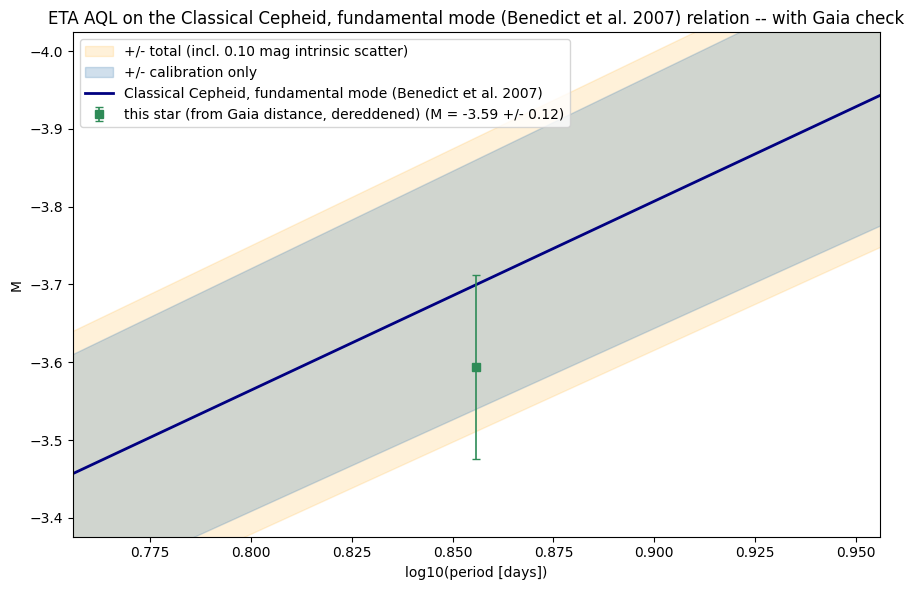

In [18]:
if period is None:
    print("No period available -- run Stage 1 successfully first.")
else:
    gaia = gaia_crosscheck(name=label) if label else None

    if gaia is not None:
        # Dereddened using Section 11/12's A_V_full -- see Section 15/16's markdown:
        # the P-L line is calibrated on dereddened photometry, so this point needs
        # the same real, physical extinction removed to be a fair comparison, not
        # left at the default A_V=0 (which would still carry this star's actual
        # foreground dust). Falls back to 0 (uncorrected) if both extinction
        # lookups failed -- flagged below, not silently swapped in.
        A_V_for_M = A_V_full if A_V_full is not None else 0.0
        A_V_err_for_M = A_V_full_err if A_V_full is not None else 0.0
        M_gaia, M_gaia_err = absmag_from_distance(
            m, gaia["d_bj_geo_pc"], gaia["d_bj_geo_err_pc"],
            A_V=A_V_for_M, A_V_err=A_V_err_for_M,
        )
    else:
        M_gaia, M_gaia_err = None, None

    summary = build_summary_table(
        period, literature_period, m, M_V, M_err,
        d_pc_noext, d_pc_noext_err, d_pc_fullext, d_pc_fullext_err, A_V_full,
        BAND, gaia, M_gaia, M_gaia_err,
    )
    print("Delta colored green/red where both sides have a quantified "
          "uncertainty (Absolute mag M, Distance): inside vs. outside the "
          "combined 1-sigma error budget. Period/Apparent mag have no error "
          "estimate on this notebook's own side, so are left uncolored.")
    display(
        summary.style
        .hide(axis="index")
        .hide(axis="columns", subset=["_DeltaVal", "_CombinedErr"])
        .apply(style_summary_row, axis=1)
    )

    if gaia is None:
        print("\nError Analysis plot skipped -- Gaia unavailable for this run.")
    else:
        plot_period = literature_period if literature_period else period
        period_source = "VSX literature period" if literature_period else "recovered period (no VSX period found)"
        print(f"\nError Analysis plotted at: {plot_period:.6f} d  ({period_source})")
        if A_V_full is not None:
            print(f"this star's point is dereddened by A_V = {A_V_full:.3f} mag "
                  f"({extinction_method}) -- a fair comparison against the P-L line's "
                  "own dereddened calibration")
            point_label = "this star (from Gaia distance, dereddened)"
        else:
            print("extinction lookup unavailable -- this star's point is NOT dereddened "
                  "(A_V=0), so it isn't a clean test of the P-L line's calibration")
            point_label = "this star (from Gaia distance, NOT dereddened)"

        fig, ax = plot_pl_relation(
            RELATION_NAME, plot_period,
            title=f"{label} on the {PL_RELATIONS[RELATION_NAME]['label']} relation -- with Gaia check",
            extra_point=(plot_period, M_gaia, M_gaia_err, point_label),
        )
        plt.show()